# Trabalho Prático 1 - INF01017
## Spot-checking de Algoritmos
### Dataset: Ames Mutagenicity

**Objetivo:** Avaliar rapidamente múltiplos algoritmos de ML para identificar os mais promissores.

---

## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)
import warnings

warnings.filterwarnings('ignore')

# Configurações
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline
import os

# Criar diretório para salvar figuras
os.makedirs('../results/figures/models/', exist_ok=True)
print('✓ Diretório de figuras criado!')

✓ Diretório de figuras criado!


## 2. Import dos Algoritmos

In [2]:
# Algoritmos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

## 3. Carregamento dos Dados Processados

In [3]:
# Carregar dados de treino e teste
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

# Separar features e target
X_train = train_df.drop(columns=['Overall'])
y_train = train_df['Overall']
X_test = test_df.drop(columns=['Overall'])
y_test = test_df['Overall']

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Shape y_test: {y_test.shape}")

Shape X_train: (3874, 1359)
Shape y_train: (3874,)
Shape X_test: (1108, 1359)
Shape y_test: (1108,)


## 4. Definição dos Modelos

In [4]:
# Dicionário com os modelos a serem testados
models = {
    # Modelos Lineares
    'Logistic Regression': LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    'SVM Linear': SVC(kernel='linear', random_state=RANDOM_SEED, probability=True),
    
    # Modelos Baseados em Árvores
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100),
    
    # Boosting
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_SEED, n_estimators=100),
    
    # Baseado em Instâncias
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    
    # Probabilístico
    'Naive Bayes': GaussianNB(),
    
    # Redes Neurais
    'MLP Neural Network': MLPClassifier(random_state=RANDOM_SEED, max_iter=500, 
                                        hidden_layer_sizes=(100, 50))
}

print(f"Número de modelos definidos: {len(models)}")
print("\nModelos:")
for i, name in enumerate(models.keys(), 1):
    print(f"  {i}. {name}")

Número de modelos definidos: 8

Modelos:
  1. Logistic Regression
  2. SVM Linear
  3. Decision Tree
  4. Random Forest
  5. Gradient Boosting
  6. K-Nearest Neighbors
  7. Naive Bayes
  8. MLP Neural Network


## 5. Função de Avaliação com Cross-Validation

In [5]:
def evaluate_model_cv(model, X, y, cv_folds=5):
    """
    Avalia modelo usando cross-validation.
    """
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_SEED)
    
    # Calcular métricas (com average='weighted' para multiclass)
    accuracy_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    precision_scores = cross_val_score(model, X, y, cv=cv, scoring='precision_weighted')
    recall_scores = cross_val_score(model, X, y, cv=cv, scoring='recall_weighted')
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted')
    roc_auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc_ovr_weighted')
    
    results = {
        'accuracy_mean': accuracy_scores.mean(),
        'accuracy_std': accuracy_scores.std(),
        'precision_mean': precision_scores.mean(),
        'precision_std': precision_scores.std(),
        'recall_mean': recall_scores.mean(),
        'recall_std': recall_scores.std(),
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'roc_auc_mean': roc_auc_scores.mean(),
        'roc_auc_std': roc_auc_scores.std()
    }
    
    return results

## 6. Spot-checking dos Modelos

In [6]:
# Realizar spot-checking
cv_folds = 5
results = []

print(f"Iniciando spot-checking com {cv_folds}-fold cross-validation...\n")

for name, model in models.items():
    print(f"Avaliando: {name}...", end=' ')
    try:
        metrics = evaluate_model_cv(model, X_train, y_train, cv_folds)
        metrics['model'] = name
        results.append(metrics)
        print(f"✓ Accuracy: {metrics['accuracy_mean']:.4f} (±{metrics['accuracy_std']:.4f})")
    except Exception as e:
        print(f"✗ ERRO: {str(e)}")

# Criar DataFrame com resultados
results_df = pd.DataFrame(results)

# Reordenar colunas
cols = ['model', 'accuracy_mean', 'accuracy_std', 'precision_mean', 'precision_std',
        'recall_mean', 'recall_std', 'f1_mean', 'f1_std', 'roc_auc_mean', 'roc_auc_std']
results_df = results_df[cols]

print("\n" + "="*60)
print("SPOT-CHECKING CONCLUÍDO!")
print("="*60)

Iniciando spot-checking com 5-fold cross-validation...

Avaliando: Logistic Regression... ✓ Accuracy: 0.8018 (±0.0154)
Avaliando: SVM Linear... ✓ Accuracy: 0.8077 (±0.0168)
Avaliando: Decision Tree... ✓ Accuracy: 0.9824 (±0.0051)
Avaliando: Random Forest... ✓ Accuracy: 0.8813 (±0.0098)
Avaliando: Gradient Boosting... ✓ Accuracy: 0.9977 (±0.0005)
Avaliando: K-Nearest Neighbors... ✓ Accuracy: 0.7457 (±0.0104)
Avaliando: Naive Bayes... ✓ Accuracy: 0.6415 (±0.0178)
Avaliando: MLP Neural Network... ✓ Accuracy: 0.8154 (±0.0115)

SPOT-CHECKING CONCLUÍDO!


## 7. Visualização dos Resultados

In [7]:
# Tabela de resultados
print("\nResultados completos:")
results_df


Resultados completos:


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.801754,0.015430,0.800079,0.014750,0.801754,0.015430,0.800398,0.014945,0.881483,0.011054
1,SVM Linear,0.807692,0.016784,0.807618,0.016793,0.807692,0.016784,0.807154,0.016670,0.891741,0.009189
2,Decision Tree,0.982448,0.005069,0.982576,0.004971,0.982448,0.005069,0.982446,0.005065,0.982892,0.004248
3,Random Forest,0.881263,0.009794,0.873579,0.025400,0.881263,0.009794,0.864297,0.010992,0.963650,0.009598
4,Gradient Boosting,0.997677,0.000515,0.997805,0.000471,0.997677,0.000515,0.997708,0.000505,0.999993,0.000012
5,K-Nearest Neighbors,0.745741,0.010404,0.725273,0.013769,0.745741,0.010404,0.733755,0.011590,0.829514,0.012145
6,Naive Bayes,0.641454,0.017755,0.654027,0.033669,0.641454,0.017755,0.585081,0.020462,0.683271,0.023439
7,MLP Neural Network,0.815435,0.011534,0.807488,0.011778,0.815435,0.011534,0.809164,0.011673,0.901598,0.011223


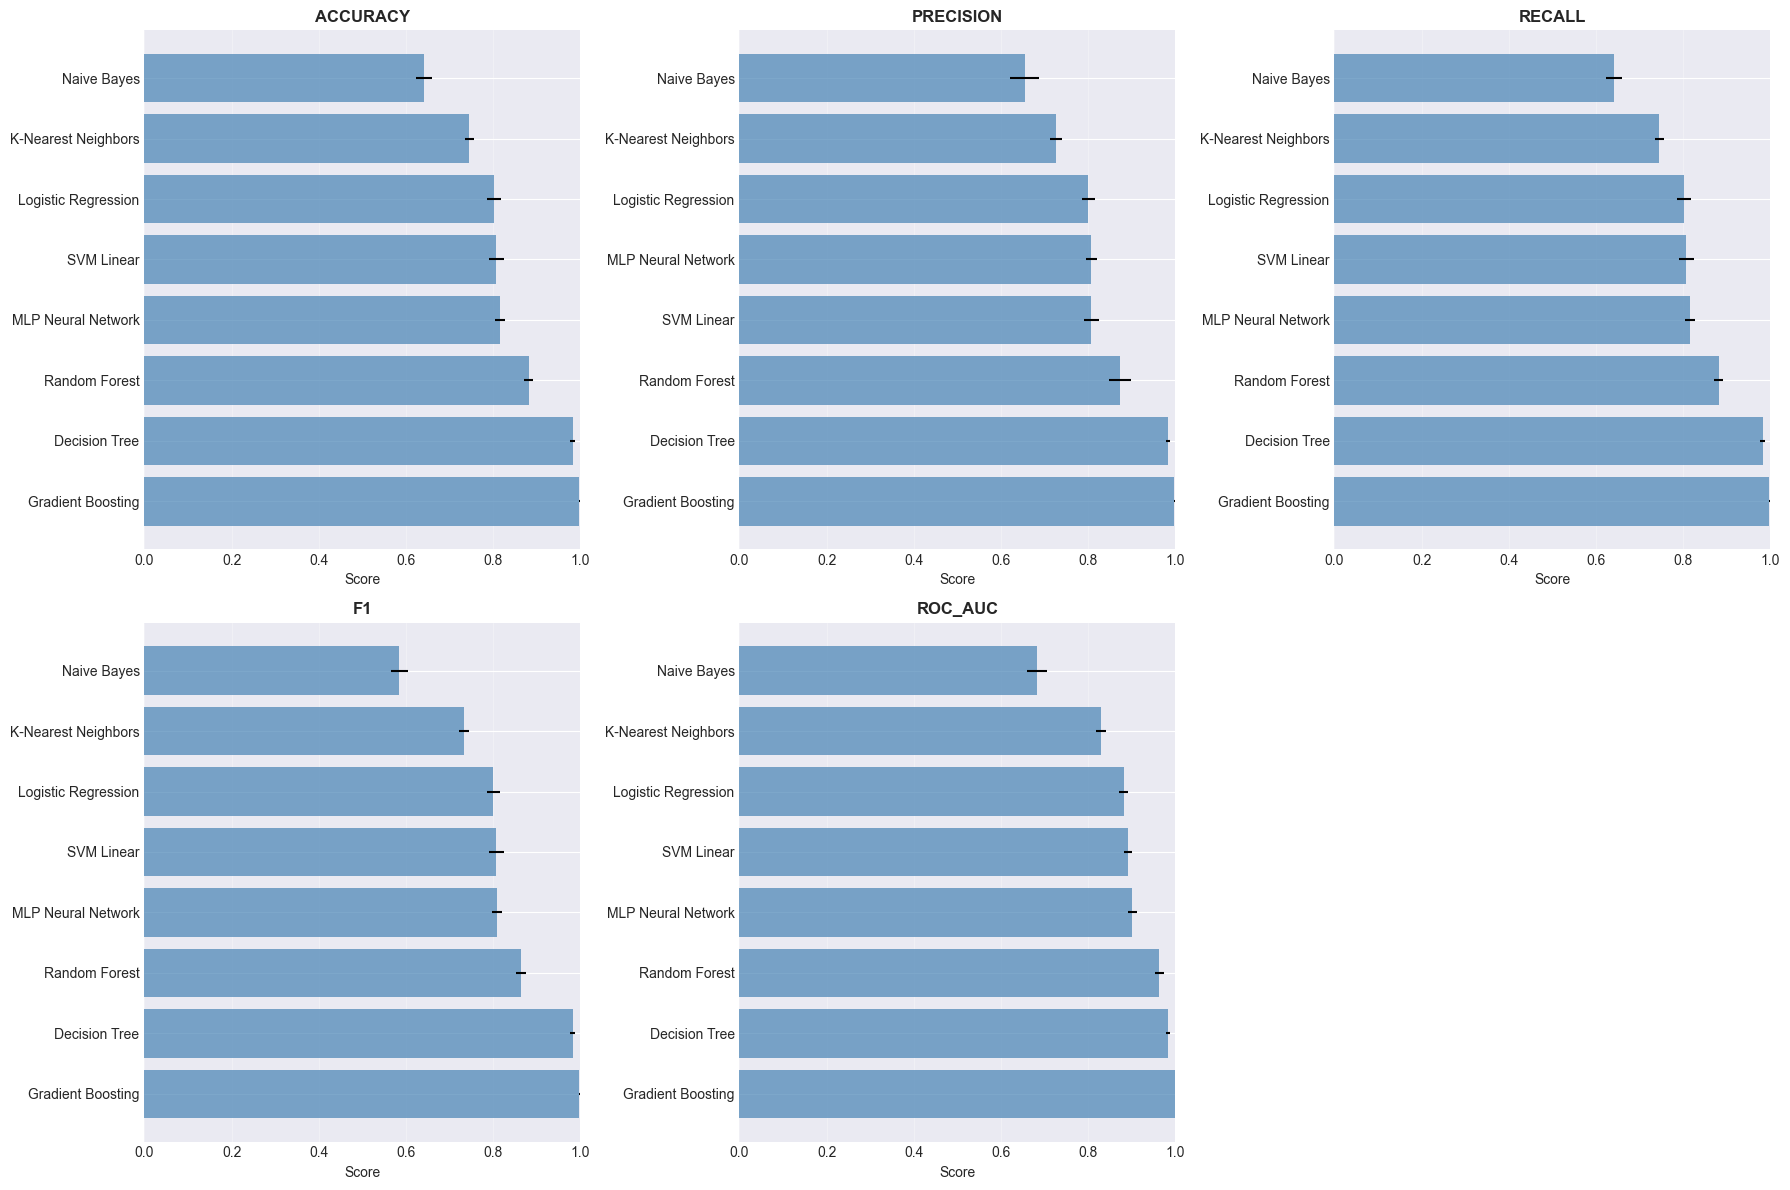

✓ Figura salva: ../results/figures/models/figure_1.png


In [8]:
# Gráficos comparativos
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, metric in enumerate(metrics):
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'
    
    results_sorted = results_df.sort_values(mean_col, ascending=False)
    
    axes[idx].barh(results_sorted['model'], results_sorted[mean_col], 
                  xerr=results_sorted[std_col], color='steelblue', alpha=0.7)
    axes[idx].set_xlabel('Score')
    axes[idx].set_title(f'{metric.upper()}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].set_xlim(0, 1)

fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig('../results/figures/models/figure_1.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Figura salva: ../results/figures/models/figure_1.png')

## 8. Ranking dos Modelos

In [9]:
# Ranquear por F1-Score (métrica principal)
ranked_df = results_df.sort_values('f1_mean', ascending=False).reset_index(drop=True)
ranked_df['rank'] = ranked_df.index + 1

print("\n" + "="*60)
print("RANKING DOS MODELOS - Métrica: F1-SCORE")
print("="*60)

for idx, row in ranked_df.head(3).iterrows():
    print(f"\n{idx+1}º lugar: {row['model']}")
    print(f"   Accuracy: {row['accuracy_mean']:.4f} (±{row['accuracy_std']:.4f})")
    print(f"   Precision: {row['precision_mean']:.4f} (±{row['precision_std']:.4f})")
    print(f"   Recall: {row['recall_mean']:.4f} (±{row['recall_std']:.4f})")
    print(f"   F1-Score: {row['f1_mean']:.4f} (±{row['f1_std']:.4f})")
    print(f"   ROC-AUC: {row['roc_auc_mean']:.4f} (±{row['roc_auc_std']:.4f})")


RANKING DOS MODELOS - Métrica: F1-SCORE

1º lugar: Gradient Boosting
   Accuracy: 0.9977 (±0.0005)
   Precision: 0.9978 (±0.0005)
   Recall: 0.9977 (±0.0005)
   F1-Score: 0.9977 (±0.0005)
   ROC-AUC: 1.0000 (±0.0000)

2º lugar: Decision Tree
   Accuracy: 0.9824 (±0.0051)
   Precision: 0.9826 (±0.0050)
   Recall: 0.9824 (±0.0051)
   F1-Score: 0.9824 (±0.0051)
   ROC-AUC: 0.9829 (±0.0042)

3º lugar: Random Forest
   Accuracy: 0.8813 (±0.0098)
   Precision: 0.8736 (±0.0254)
   Recall: 0.8813 (±0.0098)
   F1-Score: 0.8643 (±0.0110)
   ROC-AUC: 0.9637 (±0.0096)


## 9. Salvamento dos Resultados

In [10]:
import os

# Salvar resultados em CSV
output_path = '../results/metrics/'
os.makedirs(output_path, exist_ok=True)

filepath = os.path.join(output_path, 'spot_checking_results.csv')
ranked_df.to_csv(filepath, index=False)

print(f"\nResultados salvos em: {filepath}")
# Salvar ranking em formato texto (para facilitar leitura)
ranking_txt_path = os.path.join(output_path, 'ranking.txt')
with open(ranking_txt_path, 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("RANKING DOS MODELOS - Métrica: F1-SCORE\n")
    f.write("="*60 + "\n\n")
    
    for idx, row in ranked_df.head(5).iterrows():
        f.write(f"{idx+1}º lugar: {row['model']}\n")
        f.write(f"   Accuracy: {row['accuracy_mean']:.4f} (±{row['accuracy_std']:.4f})\n")
        f.write(f"   Precision: {row['precision_mean']:.4f} (±{row['precision_std']:.4f})\n")
        f.write(f"   Recall: {row['recall_mean']:.4f} (±{row['recall_std']:.4f})\n")
        f.write(f"   F1-Score: {row['f1_mean']:.4f} (±{row['f1_std']:.4f})\n")
        f.write(f"   ROC-AUC: {row['roc_auc_mean']:.4f} (±{row['roc_auc_std']:.4f})\n\n")

print(f"✓ Ranking salvo em: {ranking_txt_path}")



Resultados salvos em: ../results/metrics/spot_checking_results.csv
✓ Ranking salvo em: ../results/metrics/ranking.txt


## 10. Avaliação no Conjunto de Teste (Top 3 Modelos)


AVALIAÇÃO NO CONJUNTO DE TESTE - TOP 3 MODELOS

Modelo: Gradient Boosting

Accuracy: 0.9991
Precision: 0.9991
Recall: 0.9991
F1-Score: 0.9991
ROC-AUC: 1.0000

Relatório de Classificação:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       441
           0       0.98      1.00      0.99        46
           1       1.00      1.00      1.00       621

    accuracy                           1.00      1108
   macro avg       0.99      1.00      1.00      1108
weighted avg       1.00      1.00      1.00      1108



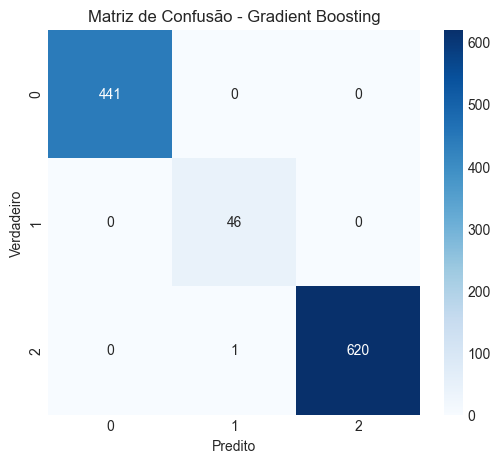

✓ Matriz de confusão salva: ../results/figures/models/confusion_matrix_Gradient_Boosting.png

Modelo: Decision Tree

Accuracy: 0.9946
Precision: 0.9947
Recall: 0.9946
F1-Score: 0.9946
ROC-AUC: 0.9958

Relatório de Classificação:
              precision    recall  f1-score   support

          -1       0.99      1.00      0.99       441
           0       0.98      1.00      0.99        46
           1       1.00      0.99      1.00       621

    accuracy                           0.99      1108
   macro avg       0.99      1.00      0.99      1108
weighted avg       0.99      0.99      0.99      1108



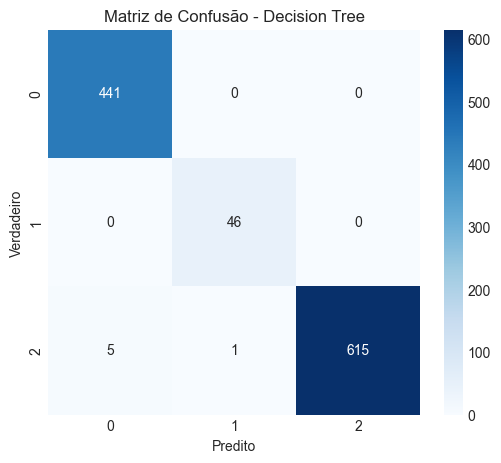

✓ Matriz de confusão salva: ../results/figures/models/confusion_matrix_Decision_Tree.png

Modelo: Random Forest

Accuracy: 0.8755
Precision: 0.8668
Recall: 0.8755
F1-Score: 0.8594
ROC-AUC: 0.9619

Relatório de Classificação:
              precision    recall  f1-score   support

          -1       0.84      0.85      0.85       441
           0       0.67      0.04      0.08        46
           1       0.90      0.95      0.93       621

    accuracy                           0.88      1108
   macro avg       0.80      0.62      0.62      1108
weighted avg       0.87      0.88      0.86      1108



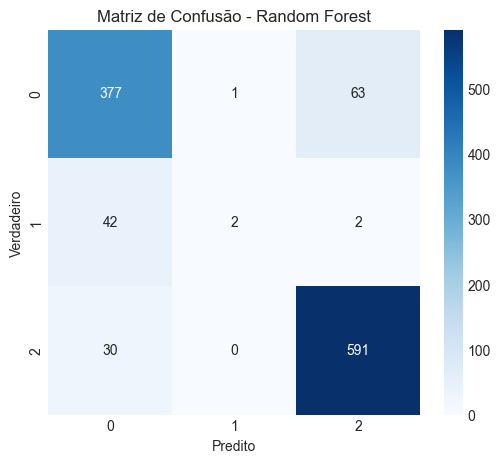

✓ Matriz de confusão salva: ../results/figures/models/confusion_matrix_Random_Forest.png

✓ Métricas de teste salvas em: ../results/metrics/test_results.csv


In [11]:
# Treinar e avaliar os top 3 modelos no conjunto de teste
print("\n" + "="*60)
print("AVALIAÇÃO NO CONJUNTO DE TESTE - TOP 3 MODELOS")
print("="*60)

top_3_models = ranked_df.head(3)['model'].tolist()

test_results = []

for model_name in top_3_models:
    print(f"\n{'='*60}")
    print(f"Modelo: {model_name}")
    print(f"{'='*60}")
    
    # Treinar modelo
    model = models[model_name]
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    
    # Métricas (com average='weighted' para multiclass)
    print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    if y_pred_proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted'):.4f}")
    
    # Relatório de classificação
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {model_name}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Predito')
    
    # Salvar figura
    fig_path = f'../results/figures/models/confusion_matrix_{model_name.replace(" ", "_")}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✓ Matriz de confusão salva: {fig_path}')
    
    # Coletar métricas
    test_results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1_score': f1_score(y_test, y_pred, average='weighted'),
        'roc_auc': roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted') if y_pred_proba is not None else None
    })

# Salvar métricas de teste
test_results_df = pd.DataFrame(test_results)
test_csv_path = '../results/metrics/test_results.csv'
test_results_df.to_csv(test_csv_path, index=False)
print(f"\n✓ Métricas de teste salvas em: {test_csv_path}")

## 11. Conclusões

**Escreva aqui as conclusões do spot-checking:**

1. Quais foram os 2-3 algoritmos mais promissores?
2. Qual métrica foi mais relevante para a decisão?
3. Houve grande variação de desempenho entre os modelos?
4. Algum modelo teve desempenho muito superior aos demais?
5. Recomendações para o T2 (otimização de hiperparâmetros)

---

**Próximo passo:** Trabalho Prático 2 - Otimização de hiperparâmetros e análise aprofundada dos modelos selecionados.

---